# Self-Attention Models: Implementation

## Introduction

In the [previous notebook](https://github.com/Maxstef/data-loves-ml-for-people-course/blob/main/notebooks/4_3_dl_sequence_modeling/0_4_self_attention_basic.ipynb), we explored the theoretical foundations of self-attention and learned how attention mechanisms enable models to capture relationships between tokens in a sequence.

The goal of this notebook is to move from theory to implementation. We will build self-attention from scratch using NumPy and examine every step of the computation in detail. Along the way, we will focus on tensor shapes, matrix operations, attention score calculation, scaling, visualization, batching, and causal masking.

By the end of this notebook, you should be able to:

* Implement a complete self-attention layer from scratch.
* Understand the role and shape of every tensor involved in the attention mechanism.
* Visualize and interpret attention matrices.
* Work with batched inputs used in real-world models.
* Understand how causal masking enables autoregressive language generation.

This notebook focuses on the practical implementation of self-attention and serves as a bridge between the mathematical foundations covered previously and the full Transformer architectures that will be explored in the [next notebook](https://github.com/Maxstef/data-loves-ml-for-people-course/blob/main/notebooks/4_3_dl_sequence_modeling/0_6_transformers_basic.ipynb).


# Section 1: Understanding Tensor Shapes

## Why Tensor Shapes Matter

Self-attention is conceptually simple:

```text
Embeddings
    ↓
Q, K, V
    ↓
Attention Scores
    ↓
Softmax
    ↓
Output
```

But every step involves matrix multiplication.

If you don't know the tensor shapes, the formulas become magic.

Our goal is:

> Understand the shape of every tensor before implementing attention.

---



## 1.1 Single Token

Let's start with a single token:

```text
cat
```

Suppose its embedding dimension is 4:

In [1]:
import numpy as np

cat = np.array([0.2, 0.8, 0.1, 0.4])

print(cat.shape)

(4,)


Interpretation:

```text
embedding_dim = 4
```

---

**Important Note**

NumPy represents this as:

```python
(4,)
```

which means:

```text
1 vector
4 values
```

---



## 1.2 A Sequence of Tokens

Now a sentence:

```text
cat sees dog
```

Let's assign embeddings:


In [2]:
import numpy as np

X = np.array([
    [0.2, 0.8, 0.1, 0.4],  # cat
    [0.5, 0.1, 0.7, 0.3],  # sees
    [0.9, 0.2, 0.4, 0.6]   # dog
])

print(X.shape)

(3, 4)


**Interpretation**

```text
(3, 4)

3 = number of tokens
4 = embedding dimension
```

Visualization:

```text
          Embedding Dimension
         ┌──────────────────┐
cat      │ 0.2 0.8 0.1 0.4 │
sees     │ 0.5 0.1 0.7 0.3 │
dog      │ 0.9 0.2 0.4 0.6 │
         └──────────────────┘

3 tokens × 4 features
```

---


## 1.3 Shape Convention

From now on:

```python
X.shape == (seq_len, d_model)
```

where:

| Symbol  | Meaning             |
| ------- | ------------------- |
| seq_len | Number of tokens    |
| d_model | Embedding dimension |

---

Example:

```python
(100, 768)
```

means:

```text
100 tokens
768-dimensional embeddings
```

---


## 1.4 Creating Query Projections

Suppose:

In [3]:
seq_len = 3
d_model = 4
d_k = 2

We create:

In [4]:
W_Q = np.random.randn(d_model, d_k)

print(W_Q.shape)

(4, 2)



**Interpretation**

```text
Input dimension  = 4
Output dimension = 2
```

This matrix converts:

```text
4-dimensional embeddings
            ↓
2-dimensional queries
```

---


## 1.5 Computing Q


In [5]:
Q = X @ W_Q

print(Q.shape)

(3, 2)



Let's reason before running it.

Shapes:

```text
X     = (3, 4)
W_Q   = (4, 2)
```

Matrix multiplication rule:

```text
(3,4) × (4,2)
      ↓
    (3,2)
```

Output:

```python
(3, 2)
```

---



## 1.6 Shapes of Q, K, V

In self-attention:

```python
Q = X @ W_Q
K = X @ W_K
V = X @ W_V
```

Typical shapes:

```python
X : (seq_len, d_model)

Q : (seq_len, d_k)
K : (seq_len, d_k)
V : (seq_len, d_v)
```

---

Example:

```python
seq_len = 3
d_model = 4
d_k = 2
d_v = 3
```

Results:

```text
X -> (3,4)

Q -> (3,2)
K -> (3,2)
V -> (3,3)
```

---



## 1.7 Computing Attention Scores

Now the famous operation:

$
QK^T
$

Suppose:

```python
Q.shape = (3, 2)
K.shape = (3, 2)
```

Then:

```python
K.T.shape = (2, 3)
```

So:

```text
(3,2) × (2,3)
      ↓
    (3,3)
```

---

**Why (3,3)?**

Because:

```text
3 query tokens
compared against
3 key tokens
```

---

Result:

```text
      cat  sees  dog
cat    ?    ?    ?
sees   ?    ?    ?
dog    ?    ?    ?
```

Every token compared with every token.

---



## 1.8 Most Important Shape in Attention

This matrix:

```python
scores.shape = (seq_len, seq_len)
```

For example:

```python
(3,3)
```

or:

```python
(100,100)
```

This is the attention matrix.

Rows:

```text
who is asking?
```

Columns:

```text
who is being attended to?
```

---



## 1.9 Final Output Shape

After softmax:

```python
weights.shape = (3,3)
```

Suppose:

```python
V.shape = (3,3)
```

Then:

```text
(3,3) × (3,3)
      ↓
    (3,3)
```

Output:

```python
output.shape = (3,3)
```

---

**Important Observation**

The output has:

* one vector per token
* context-aware information

This is what gets passed to the next layer.

---



## Practical Example

In [7]:
import numpy as np

X = np.random.randn(4, 6)

W_Q = np.random.randn(6, 3)
W_K = np.random.randn(6, 3)
W_V = np.random.randn(6, 5)

Q = X @ W_Q
K = X @ W_K
V = X @ W_V

scores = Q @ K.T

print(f'X shape: {X.shape}')
print(f'W_Q shape: {W_Q.shape}')
print(f'W_K shape: {W_K.shape}')
print(f'W_V shape: {W_V.shape}')
print(f'Q shape: {Q.shape}')
print(f'K shape: {K.shape}')
print(f'V shape: {V.shape}')
print(f'scores shape: {scores.shape}')


X shape: (4, 6)
W_Q shape: (6, 3)
W_K shape: (6, 3)
W_V shape: (6, 5)
Q shape: (4, 3)
K shape: (4, 3)
V shape: (4, 5)
scores shape: (4, 4)



# Section 2: Building a Self-Attention Layer from Scratch

## Learning Objectives

By the end of this section, you should be able to:

* Implement a reusable self-attention class
* Follow every tensor transformation
* Inspect intermediate outputs
* Understand what happens during a forward pass
* Relate code directly to the mathematical formula

---



## Step 1 - Start with a Simple Dataset

Let's create a tiny sequence.


In [8]:
import numpy as np

np.set_printoptions(precision=3, suppress=True)

tokens = ["cat", "sees", "dog"]

X = np.array([
    [1.0, 0.0, 0.5, 0.2],  # cat
    [0.3, 1.0, 0.1, 0.8],  # sees
    [0.8, 0.2, 1.0, 0.1]   # dog
])

print("Input shape:", X.shape)
print(X)

Input shape: (3, 4)
[[1.  0.  0.5 0.2]
 [0.3 1.  0.1 0.8]
 [0.8 0.2 1.  0.1]]


Meaning:

```text
3 tokens
4-dimensional embeddings
```


## Step 2 - Define Self-Attention Class

Let's build the smallest possible version.


In [27]:
class SelfAttention:

    def __init__(self, d_model, d_k, d_v):
        self.W_Q = np.random.randn(d_model, d_k)
        self.W_K = np.random.randn(d_model, d_k)
        self.W_V = np.random.randn(d_model, d_v)

    def softmax(self, x):
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    def forward(self, X):

        Q = X @ self.W_Q
        K = X @ self.W_K
        V = X @ self.W_V

        scores = Q @ K.T

        attention = self.softmax(scores)

        output = attention @ V

        return output



## Step 3 - Run It


In [30]:
np.random.seed(42)

attention = SelfAttention(
    d_model=4,
    d_k=2,
    d_v=4
)

output = attention.forward(X)

print(output.shape)
print(output)


(3, 4)
[[-0.953  0.197 -1.637 -0.773]
 [-1.309  0.29  -1.632 -0.84 ]
 [-0.862  0.162 -1.568 -0.744]]


This already works.

We have implemented:

```text
Q = XW_Q

K = XW_K

V = XW_V

Attention = softmax(QKᵀ)

Output = AttentionV
```

which is the entire core of self-attention.



## Step 4 - Make It Explain Itself

The version above hides too much.

For learning purposes, let's expose everything.



In [31]:
class SelfAttentionVerbose:

    def __init__(self, d_model, d_k, d_v):
        self.W_Q = np.random.randn(d_model, d_k)
        self.W_K = np.random.randn(d_model, d_k)
        self.W_V = np.random.randn(d_model, d_v)

    def softmax(self, x):
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    def forward(self, X):

        Q = X @ self.W_Q
        K = X @ self.W_K
        V = X @ self.W_V

        scores = Q @ K.T

        attention = self.softmax(scores)

        output = attention @ V

        print("\n=== Q ===")
        print(Q)

        print("\n=== K ===")
        print(K)

        print("\n=== V ===")
        print(V)

        print("\n=== Scores ===")
        print(scores)

        print("\n=== Attention Weights ===")
        print(attention)

        print("\n=== Output ===")
        print(output)

        return output


## Step 5 - Connect Outputs to Shapes

In [14]:
X.shape

(3, 4)

In [33]:
np.random.seed(42)

attention = SelfAttentionVerbose(
    d_model=4,
    d_k=2,
    d_v=4
)

output = attention.forward(X)

print(output.shape)
print(output)



=== Q ===
[[ 0.695 -0.102]
 [ 2.037  2.072]
 [ 0.451  0.037]]

=== K ===
[[-0.693 -0.527]
 [-1.96  -0.944]
 [-0.399 -1.629]]

=== V ===
[[-1.405  0.311 -1.604 -0.854]
 [ 0.627 -0.354 -0.801 -0.329]
 [-1.122  0.288 -1.924 -0.854]]

=== Scores ===
[[-0.429 -1.267 -0.111]
 [-2.503 -5.948 -4.187]
 [-0.332 -0.918 -0.239]]

=== Attention Weights ===
[[0.356 0.154 0.489]
 [0.821 0.026 0.153]
 [0.377 0.21  0.413]]

=== Output ===
[[-0.953  0.197 -1.637 -0.773]
 [-1.309  0.29  -1.632 -0.84 ]
 [-0.862  0.162 -1.568 -0.744]]
(3, 4)
[[-0.953  0.197 -1.637 -0.773]
 [-1.309  0.29  -1.632 -0.84 ]
 [-0.862  0.162 -1.568 -0.744]]


## Step 6 - Add Scaling (Real Transformer Version)


Current:

```python
scores = Q @ K.T
```

Real Transformer:

```python
scores = (Q @ K.T) / np.sqrt(K.shape[1])
```

or:

```python
d_k = K.shape[1]

scores = (Q @ K.T) / np.sqrt(d_k)
```

This gives us:

$
\text{Attention}(Q,K,V)=\text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$

which is the actual Transformer attention formula.



In [34]:
class SelfAttention:

    def __init__(self, d_model, d_k, d_v, verbose=False):
        self.W_Q = np.random.randn(d_model, d_k)
        self.W_K = np.random.randn(d_model, d_k)
        self.W_V = np.random.randn(d_model, d_v)

        self.verbose = verbose

    def softmax(self, x):
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    def forward(self, X):

        Q = X @ self.W_Q
        K = X @ self.W_K
        V = X @ self.W_V

        # scaling update
        d_k = K.shape[1]
        scores = (Q @ K.T) / np.sqrt(d_k)

        attention = self.softmax(scores)

        output = attention @ V

        if self.verbose:
            print("\n=== Q ===")
            print(Q)

            print("\n=== K ===")
            print(K)

            print("\n=== V ===")
            print(V)

            print("\n=== Scores ===")
            print(scores)

            print("\n=== Attention Weights ===")
            print(attention)

            print("\n=== Output ===")
            print(output)

        return output


In [35]:
np.random.seed(42)

attention = SelfAttention(
    d_model=4,
    d_k=2,
    d_v=4
)

output = attention.forward(X)

print(output.shape)
print(output)


(3, 4)
[[-0.878  0.17  -1.589 -0.75 ]
 [-1.215  0.264 -1.623 -0.821]
 [-0.802  0.141 -1.535 -0.727]]



# Section 3: Scaled Attention in Practice

## Learning Objectives

By the end of this section, you should be able to:

* Observe how attention scores grow with dimension
* See softmax saturation happen
* Understand why √dₖ scaling is necessary
* Compare scaled vs unscaled attention
* Develop intuition for numerical stability

---



## 3.1 Quick Refresher

Current attention:

$
\text{softmax}(QK^T)V
$

Transformer attention:

$
\text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$

Question:

> Why divide by √dₖ?

Let's observe it experimentally.

---


## 3.2 Softmax Saturation

First create a helper:


In [36]:
import numpy as np

def softmax(x):
    exp_x = np.exp(x - np.max(x))
    return exp_x / exp_x.sum()

In [38]:
# examples
scores = np.array([2, 1, 0])

print(softmax(scores))

[0.665 0.245 0.09 ]


In [40]:
scores = np.array([20, 10, 0])

print(softmax(scores))

[1. 0. 0.]



**Observation**

The relative ordering didn't change:

```text
20 > 10 > 0
```

but softmax became extremely confident.

This is softmax saturation.

---



## 3.3 Simulating Different Dimensions

Let's investigate dot products.



In [42]:
import numpy as np

np.random.seed(42)

for d in [2, 8, 32, 128, 512]:
    q = np.random.randn(d)
    k = np.random.randn(d)

    score = np.dot(q, k)

    print(f"d={d:3d} | score={score:.3f}")

d=  2 | score=0.111
d=  8 | score=-1.040
d= 32 | score=-6.541
d=128 | score=13.216
d=512 | score=8.639



As dimension grows:

```text
d=2
d=8
d=32
d=128
d=512
```

scores tend to become more extreme.

Not always larger in absolute value every run, but their variance increases significantly.

---


## 3.4 Large Experiment

Let's collect statistics.



In [43]:
import numpy as np

np.random.seed(42)

dimensions = [2, 8, 32, 128, 512]

for d in dimensions:

    scores = []

    for _ in range(1000):
        q = np.random.randn(d)
        k = np.random.randn(d)

        scores.append(np.dot(q, k))

    scores = np.array(scores)

    print(
        f"d={d:3d} | "
        f"mean={scores.mean():.3f} | "
        f"std={scores.std():.3f}"
    )

d=  2 | mean=-0.032 | std=1.366
d=  8 | mean=0.058 | std=2.976
d= 32 | mean=0.037 | std=5.432
d=128 | mean=-0.444 | std=11.700
d=512 | mean=-0.073 | std=22.517



**Key Observation**

You'll notice:

```text
std ≈ √d
```

which is exactly why the transformer paper introduced scaling.



## 3.5 Compare Raw vs Scaled

Now normalize.


In [44]:
import numpy as np

np.random.seed(42)

dimensions = [2, 8, 32, 128, 512]

for d in dimensions:

    raw_scores = []
    scaled_scores = []

    for _ in range(1000):

        q = np.random.randn(d)
        k = np.random.randn(d)

        score = np.dot(q, k)

        raw_scores.append(score)
        scaled_scores.append(score / np.sqrt(d))

    raw_scores = np.array(raw_scores)
    scaled_scores = np.array(scaled_scores)

    print(
        f"d={d:3d} | "
        f"raw_std={raw_scores.std():.3f} | "
        f"scaled_std={scaled_scores.std():.3f}"
    )

d=  2 | raw_std=1.366 | scaled_std=0.966
d=  8 | raw_std=2.976 | scaled_std=1.052
d= 32 | raw_std=5.432 | scaled_std=0.960
d=128 | raw_std=11.700 | scaled_std=1.034
d=512 | raw_std=22.517 | scaled_std=0.995



## 3.6 Visualize the Difference

This is probably the most educational experiment.


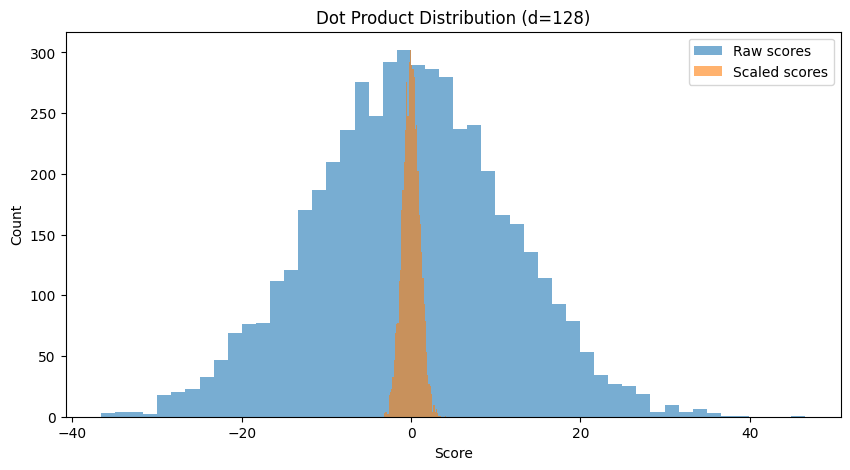

In [47]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_distribution(d=128):
    raw_scores = []
    scaled_scores = []

    for _ in range(5000):
        q = np.random.randn(d)
        k = np.random.randn(d)

        score = np.dot(q, k)

        raw_scores.append(score)
        scaled_scores.append(score / np.sqrt(d))

    plt.figure(figsize=(10, 5))

    plt.hist(raw_scores, bins=50, alpha=0.6, label="Raw scores")
    plt.hist(scaled_scores, bins=50, alpha=0.6, label="Scaled scores")

    plt.legend()
    plt.title(f"Dot Product Distribution (d={d})")
    plt.xlabel("Score")
    plt.ylabel("Count")

    plt.show()

np.random.seed(42)

visualize_distribution()

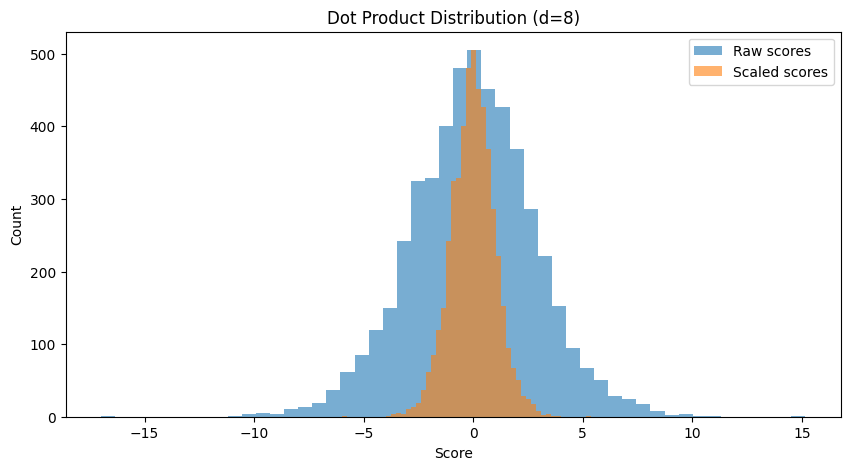

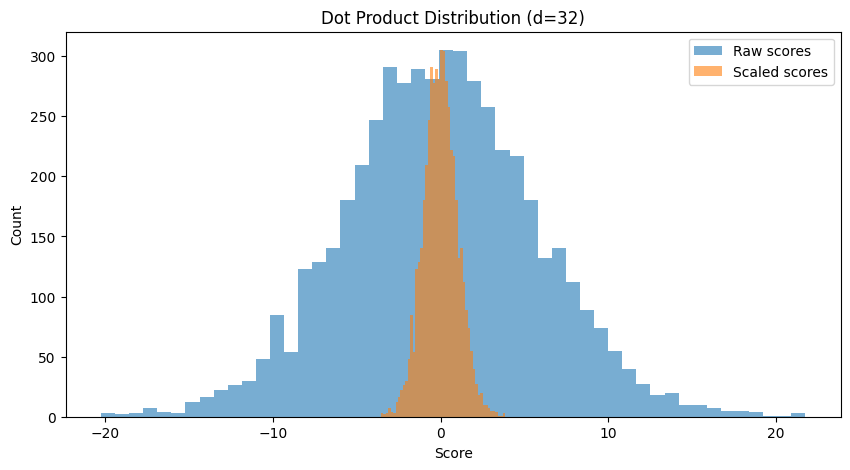

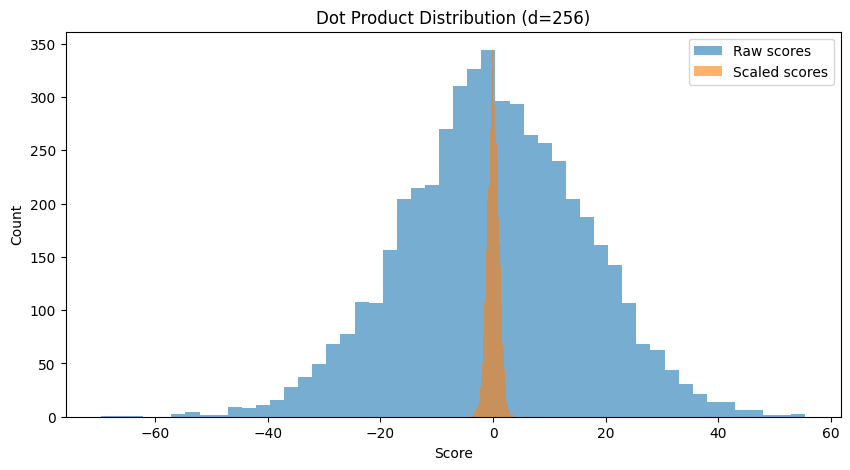

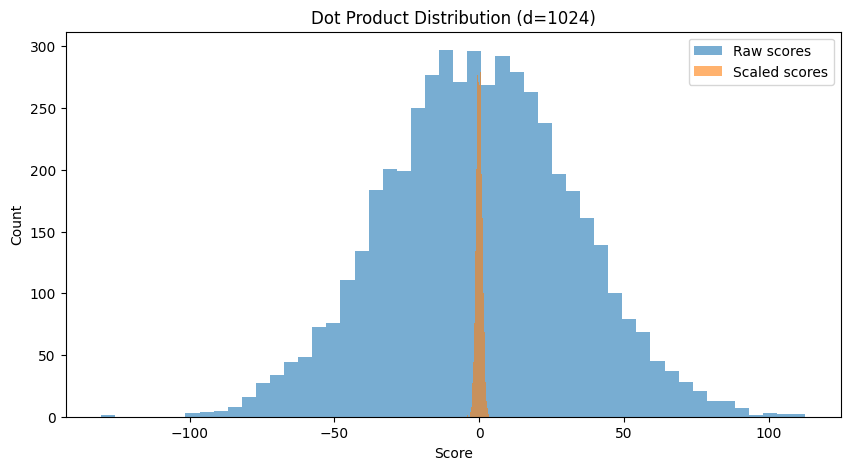

In [50]:
np.random.seed(42)

visualize_distribution(d=8)
visualize_distribution(d=32)
visualize_distribution(d=256)
visualize_distribution(1024)

## Section Summary

* Larger dimensions produce larger dot-product variance.
* Large scores cause softmax saturation.
* Saturated softmax leads to poor learning dynamics.
* Dividing by √dₖ stabilizes score distributions.
* This is why modern transformers use scaled dot-product attention.


# Section 4: Visualizing Attention

## Learning Objectives

By the end of this section, you should be able to:

* Visualize attention as a heatmap
* Interpret attention matrices
* Identify self-attention patterns
* Identify cross-token attention patterns
* Connect attention weights to token relationships

---



## 4.1 First Heatmap

Let's start with a manually defined attention matrix.


In [51]:
import numpy as np

tokens = ["cat", "sees", "dog"]

attention = np.array([
    [0.8, 0.1, 0.1],
    [0.4, 0.2, 0.4],
    [0.1, 0.1, 0.8]
])

### Visualization Code

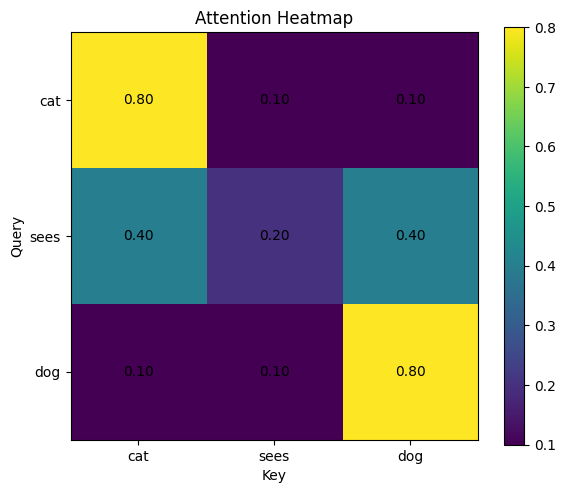

In [52]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(attention)

ax.set_xticks(range(len(tokens)))
ax.set_yticks(range(len(tokens)))

ax.set_xticklabels(tokens)
ax.set_yticklabels(tokens)

ax.set_xlabel("Key")
ax.set_ylabel("Query")

ax.set_title("Attention Heatmap")

for i in range(attention.shape[0]):
    for j in range(attention.shape[1]):
        ax.text(
            j,
            i,
            f"{attention[i,j]:.2f}",
            ha="center",
            va="center"
        )

fig.colorbar(im)

plt.tight_layout()
plt.show()


## 4.2 Read the Heatmap

The most important rule:

**Rows = Queries**

```text
Who is asking?
```

---

**Columns = Keys**

```text
Who is being attended to?
```

---

Example:

Cell:

```python
attention[1, 0] = 0.4
```

means:

> "sees" attends 40% to "cat"

---

## 4.3 What Pattern Do You See?

Matrix:

```python
[
 [0.8, 0.1, 0.1],
 [0.4, 0.2, 0.4],
 [0.1, 0.1, 0.8]
]
```

Interpretation:

**cat**

```python
[0.8, 0.1, 0.1]
```

Mostly attends to itself.

---

**dog**

```python
[0.1, 0.1, 0.8]
```

Mostly attends to itself.

---

**sees**

```python
[0.4, 0.2, 0.4]
```

Attends equally to:

* cat
* dog

This actually makes linguistic sense.

The verb connects subject and object.

---



## 4.4 Visualize Real Attention

change above implementation and extend with returning attention values in forward function

In [53]:
class SelfAttention:

    def __init__(self, d_model, d_k, d_v):
        self.W_Q = np.random.randn(d_model, d_k)
        self.W_K = np.random.randn(d_model, d_k)
        self.W_V = np.random.randn(d_model, d_v)

    def softmax(self, x):
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    def forward(self, X):

        Q = X @ self.W_Q
        K = X @ self.W_K
        V = X @ self.W_V

        # scaling update
        d_k = K.shape[1]
        scores = (Q @ K.T) / np.sqrt(d_k)

        attention = self.softmax(scores)

        output = attention @ V

        return output, attention


In [58]:
np.random.seed(42)

attention_layer = SelfAttention(
    d_model=4,
    d_k=2,
    d_v=4
)

output, attention = attention_layer.forward(X)

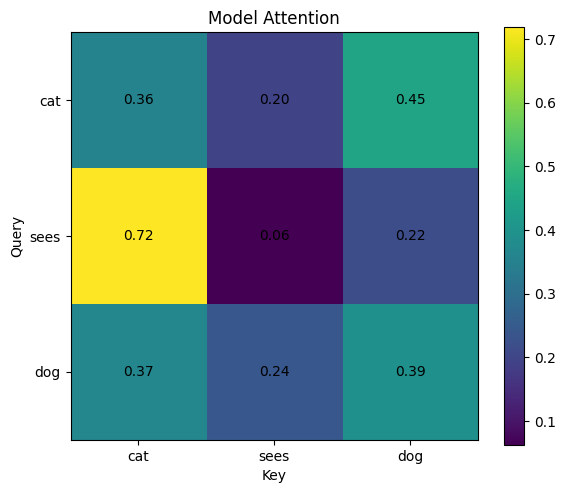

In [59]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,5))

im = ax.imshow(attention)

ax.set_xticks(range(len(tokens)))
ax.set_yticks(range(len(tokens)))

ax.set_xticklabels(tokens)
ax.set_yticklabels(tokens)

ax.set_xlabel("Key")
ax.set_ylabel("Query")

ax.set_title("Model Attention")

for i in range(attention.shape[0]):
    for j in range(attention.shape[1]):
        ax.text(
            j,
            i,
            f"{attention[i,j]:.2f}",
            ha="center",
            va="center"
        )

fig.colorbar(im)

plt.tight_layout()
plt.show()


Because:

```python
W_Q
W_K
W_V
```

are random,

the attention pattern is also random.


# Section 5: Batch Dimension

## Learning Objectives

By the end of this section, you should be able to:

* Understand why batching exists
* Work with 3D tensors
* Implement batched self-attention
* Understand tensor shapes used in real transformers
* Prepare for PyTorch implementations

---



## 5.1 Why Do We Need Batches?

Suppose we have:

```text
Sentence 1: "cat sees dog"
Sentence 2: "bird likes seeds"
Sentence 3: "fish swims fast"
```

Instead of processing:

```text
Sentence 1
then Sentence 2
then Sentence 3
```

we process all simultaneously.

Why?

* Faster GPU utilization
* More efficient matrix operations
* Better training throughput

---



## 5.2 New Shape Convention

Previously:

```python
X.shape = (seq_len, d_model)
```

Now:

```python
X.shape = (batch_size, seq_len, d_model)
```

---

Example:

```python
X.shape = (2, 3, 4)
```

means:

```text
2 sentences
3 tokens each
4-dimensional embeddings
```

---



## Visualizing the Tensor

```text
Sentence 1

cat     [0.2 0.8 0.1 0.4]
sees    [0.5 0.1 0.7 0.3]
dog     [0.9 0.2 0.4 0.6]

Sentence 2

bird    [0.3 0.7 0.2 0.5]
likes   [0.8 0.2 0.9 0.1]
seeds   [0.4 0.4 0.5 0.5]
```

Shape:

```python
(2,3,4)
```

---



## 5.3 Create a Batch


In [60]:
import numpy as np

X = np.array([
    [
        [1.0, 0.0, 0.5, 0.2],
        [0.3, 1.0, 0.1, 0.8],
        [0.8, 0.2, 1.0, 0.1]
    ],
    [
        [0.4, 0.8, 0.2, 0.1],
        [0.7, 0.1, 0.6, 0.3],
        [0.2, 0.9, 0.3, 0.7]
    ]
])

print(X.shape)


(2, 3, 4)



## 5.4 Computing Q, K, V

This is the cool part.

The exact same code works:


In [63]:
X.shape

(2, 3, 4)

In [71]:
W_Q = np.random.randn(4, 2)
W_K = np.random.randn(4, 2)
W_V = np.random.randn(4, 3)

In [69]:
Q = X @ W_Q
K = X @ W_K
V = X @ W_V

In [74]:
W_Q.shape, Q.shape

((4, 2), (2, 3, 2))

**Interpretation**

```text
2 sentences
3 tokens
2-dimensional queries
```


## 5.5 Batched Attention Scores

Previously:

```python
scores = Q @ K.T
```

worked because tensors were 2D.

Now we have 3D tensors.

We need:

```python
scores = Q @ np.transpose(K, (0, 2, 1))
```

---



Let's inspect shapes.

**K**

```python
(2,3,2)
```

**Transpose**

```python
(2,2,3)
```

Notice:

```text
batch dimension stays untouched
```

Only the last two dimensions swap.

---

Then:

```text
(2,3,2)
×
(2,2,3)

↓

(2,3,3)
```

---

**What Does (2,3,3) Mean?**

```python
scores.shape = (2,3,3)
```

Interpretation:

```text
Sentence 1:
    3×3 attention matrix

Sentence 2:
    3×3 attention matrix
```

Each sentence gets its own attention matrix.




## 5.6 Softmax

Same idea:

```python
attention = softmax(scores)
```

except now we normalize along:

```python
axis=-1
```

---


In [75]:
def softmax(x):
    exp_x = np.exp(
        x - np.max(x, axis=-1, keepdims=True)
    )

    return exp_x / np.sum(
        exp_x,
        axis=-1,
        keepdims=True
    )


## 5.7 Final Output

```python
output = attention @ V
```

Shapes:

```text
attention
(2,3,3)

V
(2,3,4)

↓

output
(2,3,4)
```

---

**Important Observation**

Input:

```python
(2,3,4)
```

Output:

```python
(2,3,4)
```

Exactly the same shape.

Just like in real transformers.

---


## Full Batched Attention Example

In [77]:
import numpy as np

np.random.seed(42)

batch_size = 8
seq_len = 20
d_model = 128
d_k = 32

X = np.random.randn(
    batch_size,
    seq_len,
    d_model
)

W_Q = np.random.randn(d_model, d_k)
W_K = np.random.randn(d_model, d_k)
W_V = np.random.randn(d_model, d_model)

Q = X @ W_Q
K = X @ W_K
V = X @ W_V

scores = (
    Q @ np.transpose(K, (0,2,1))
) / np.sqrt(d_k)

def softmax(x):
    exp_x = np.exp(
        x - np.max(x, axis=-1, keepdims=True)
    )

    return exp_x / np.sum(
        exp_x,
        axis=-1,
        keepdims=True
    )

attention = softmax(scores)

output = attention @ V

print("X:", X.shape)
print("Q:", Q.shape)
print("K:", K.shape)
print("V:", V.shape)
print("scores:", scores.shape)
print("attention:", attention.shape)
print("output:", output.shape)


X: (8, 20, 128)
Q: (8, 20, 32)
K: (8, 20, 32)
V: (8, 20, 128)
scores: (8, 20, 20)
attention: (8, 20, 20)
output: (8, 20, 128)


# Section 6: Causal Masking 

## Why Do We Need It?

Suppose we train a language model on:

```text id="b7ln2y"
I love machine learning
```

When predicting:

```text id="9x1zh8"
machine
```

the model should only see:

```text id="xxy3n9"
I love
```

and NOT:

```text id="igys8j"
learning
```

Otherwise it could cheat.

---



## The Problem

Regular self-attention allows:

```text id="ayr79g"
token 1 → token 4
token 2 → token 4
token 3 → token 4
```

and also:

```text id="hnhkz8"
token 3 ← token 4
```

meaning future tokens can influence past tokens.

For language generation this is forbidden.

---



## The Solution

We apply a mask before softmax.

For a sequence of length 4:

```python
mask = np.array([
    [0,  -np.inf, -np.inf, -np.inf],
    [0,   0,      -np.inf, -np.inf],
    [0,   0,       0,      -np.inf],
    [0,   0,       0,       0]
])
```



Visualization:

```text id="l2j92d"
✓ ✗ ✗ ✗
✓ ✓ ✗ ✗
✓ ✓ ✓ ✗
✓ ✓ ✓ ✓
```

Meaning:

```text id="qv7ct6"
Can attend to:
- itself
- previous tokens

Cannot attend to:
- future tokens
```

---

**Apply Mask**

Before:

```python
scores = Q @ K.T
```

After:

```python
scores = scores + mask
```

Then:

```python
attention = softmax(scores)
```

---

**What Happens?**

Suppose:

```python
scores = [2, 1, 5, 3]
```

and the last two positions are masked:

```python
scores = [2, 1, -np.inf, -np.inf]
```

After softmax:

```python
[0.73, 0.27, 0.0, 0.0]
```

The model literally cannot attend to future tokens.

---



## Creating a Mask in NumPy

In [78]:
seq_len = 5

mask = np.triu(
    np.ones((seq_len, seq_len)),
    k=1
)

mask = np.where(mask == 1, -np.inf, 0)

print(mask)

[[  0. -inf -inf -inf -inf]
 [  0.   0. -inf -inf -inf]
 [  0.   0.   0. -inf -inf]
 [  0.   0.   0.   0. -inf]
 [  0.   0.   0.   0.   0.]]


**Why Is This Important?**

This single idea is what allows GPT models to generate text one token at a time.

Without masking:

```text id="8trhr7"
Model can see the future
```

With masking:

```text id="yw2n7s"
Model only sees the past
```

which matches the actual generation process.

---

# Conclusion

In this notebook, we implemented self-attention from scratch and developed a practical understanding of how it works in modern Transformer models.

We learned how to:

* Work with tensor shapes used in attention mechanisms.
* Build a self-attention layer using NumPy.
* Compute Query, Key, and Value projections.
* Apply scaled dot-product attention.
* Visualize and interpret attention matrices.
* Process batched inputs.
* Use causal masking for autoregressive language models.

By the end of this notebook, self-attention is no longer a black box. We can now understand and implement the complete attention mechanism that serves as the foundation of Transformer architectures.

In the [next notebook](https://github.com/Maxstef/data-loves-ml-for-people-course/blob/main/notebooks/4_3_dl_sequence_modeling/0_6_transformers_basic.ipynb), we will build complete Transformer blocks by introducing multi-head attention, positional encoding, residual connections, and the architecture used in models such as GPT.
